# Day 17 — Regression: OLS, Ridge, Lasso, ElasticNet
## Week 2: Regression | Digital Consumer Platform Analytics

---

### Learning Objectives
- Derive OLS analytically — the normal equation
- Understand OLS assumptions and what happens when they break
- Derive Ridge and Lasso from a geometric / Lagrangian perspective
- Understand why Lasso produces sparse solutions while Ridge doesn't
- Apply residual diagnostics to detect assumption violations

---

### Dataset
**UCI Online Retail II** — predicting Customer Lifetime Value (LTV) from behavioral features.

---

## Part 1: Theory

### 17.1 OLS — The Normal Equation

**Model:** $y = X\beta + \epsilon$

**Objective:** Minimize residual sum of squares:
$$\text{RSS}(\beta) = \|y - X\beta\|^2 = (y - X\beta)^T(y - X\beta)$$

**Derive the solution:** Take gradient and set to zero:
$$\frac{\partial \text{RSS}}{\partial \beta} = -2X^T(y - X\beta) = 0$$
$$X^TX\beta = X^Ty$$
$$\hat{\beta} = (X^TX)^{-1}X^Ty$$

This is the **normal equation** — the closed-form solution to OLS.

**When $(X^TX)^{-1}$ doesn't exist:** When features are perfectly collinear. Ridge regression adds a diagonal term to make the matrix invertible.

---

### 17.2 OLS Assumptions (Gauss-Markov)

**1. Linearity:** $E[y|X] = X\beta$ — the true relationship is linear.

**2. Exogeneity:** $E[\epsilon|X] = 0$ — errors are uncorrelated with features. Violated by omitted variables, simultaneity.

**3. Homoscedasticity:** $\text{Var}(\epsilon_i) = \sigma^2$ — constant error variance. Violated when variance changes with X (e.g. higher spend customers have more variable behavior).

**4. No autocorrelation:** $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ for $i \neq j$. Violated for time series, clustered data.

**5. No perfect multicollinearity:** $X$ has full column rank. Violated when features are linearly dependent.

Under assumptions 1–5: OLS is BLUE (Best Linear Unbiased Estimator) — Gauss-Markov theorem.

---

### 17.3 Ridge Regression (L2 Regularization)

**Problem:** When features are correlated, $(X^TX)^{-1}$ is near-singular → estimates are unstable (high variance).

**Ridge adds an L2 penalty:**
$$\hat{\beta}_{Ridge} = \arg\min_\beta \|y - X\beta\|^2 + \lambda \|\beta\|^2$$

**Closed-form solution:**
$$\hat{\beta}_{Ridge} = (X^TX + \lambda I)^{-1}X^Ty$$

Adding $\lambda I$ to the diagonal makes the matrix invertible → stable estimates.

**Geometric interpretation:** Ridge shrinks all coefficients toward zero, but never exactly to zero. The constraint region is a sphere — the optimal $\beta$ hits the sphere tangentially, rarely at a corner (where one coefficient would be zero).

**Effect on coefficients:** As $\lambda$ increases, all $|\hat{\beta}_j| \to 0$. Ridge does not perform variable selection.

---

### 17.4 Lasso Regression (L1 Regularization)

**Lasso adds an L1 penalty:**
$$\hat{\beta}_{Lasso} = \arg\min_\beta \|y - X\beta\|^2 + \lambda \|\beta\|_1$$

No closed-form solution — requires coordinate descent.

**Geometric interpretation:** The L1 constraint region is a diamond (polytope) with corners on the axes. The optimal $\beta$ is more likely to hit a corner, where some coefficients = 0.

**Sparse solutions:** As $\lambda$ increases, Lasso sets some coefficients exactly to zero — performs variable selection automatically.

**When Lasso > Ridge:**
- True model is sparse (only a few features matter)
- Feature selection is valuable for interpretation

**When Ridge > Lasso:**
- All features contribute a little (dense true model)
- Correlated features — Lasso tends to arbitrarily select one and zero out the rest

---

### 17.5 ElasticNet

Combines L1 and L2 penalties:
$$\hat{\beta}_{EN} = \arg\min_\beta \|y - X\beta\|^2 + \lambda_1 \|\beta\|_1 + \lambda_2 \|\beta\|^2$$

**l1_ratio** parameter: 0 = pure Ridge, 1 = pure Lasso.

**When ElasticNet wins:** Correlated features + you want sparse solutions. Lasso tends to select one from each correlated group arbitrarily. ElasticNet tends to include or exclude correlated groups together (grouping effect).

---

### 17.6 Residual Diagnostics

Four key diagnostic plots:

**1. Residuals vs Fitted:** 
- Should show: random scatter around zero
- Red flag: systematic pattern (non-linearity), funnel shape (heteroscedasticity)

**2. Q-Q Plot (Normal Probability Plot):**
- Should show: residuals on the straight line
- Red flag: S-shape (skewed), heavy tails (outliers)

**3. Scale-Location Plot:**
- Y-axis: $\sqrt{|standardized residuals|}$
- Should show: flat trend (homoscedasticity)
- Red flag: increasing trend (variance grows with fitted values)

**4. Residuals vs Leverage:**
- Leverage: how influential is each point on the regression line?
- Cook's Distance: combines leverage and residual size
- Red flag: high leverage + high residual = influential outlier

---

## Part 2: Practice

---

In [ ]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Load customer LTV from Day 9 segmentation output (or rebuild)
try:
    df = pd.read_csv(r'C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\customer_segments.csv')
    feature_cols = [c for c in df.columns if c not in ['Customer ID', 'KMeans_Cluster', 
                                                         'Cluster_Name', 'UMAP1', 'UMAP2']]
    print(f"Loaded Day 9 output: {df.shape}")
    print(f"Features available: {feature_cols}")
except FileNotFoundError:
    print("Rebuild customer features from UCI Online Retail")

MODEL 1: Monetary ~ features (raw target)


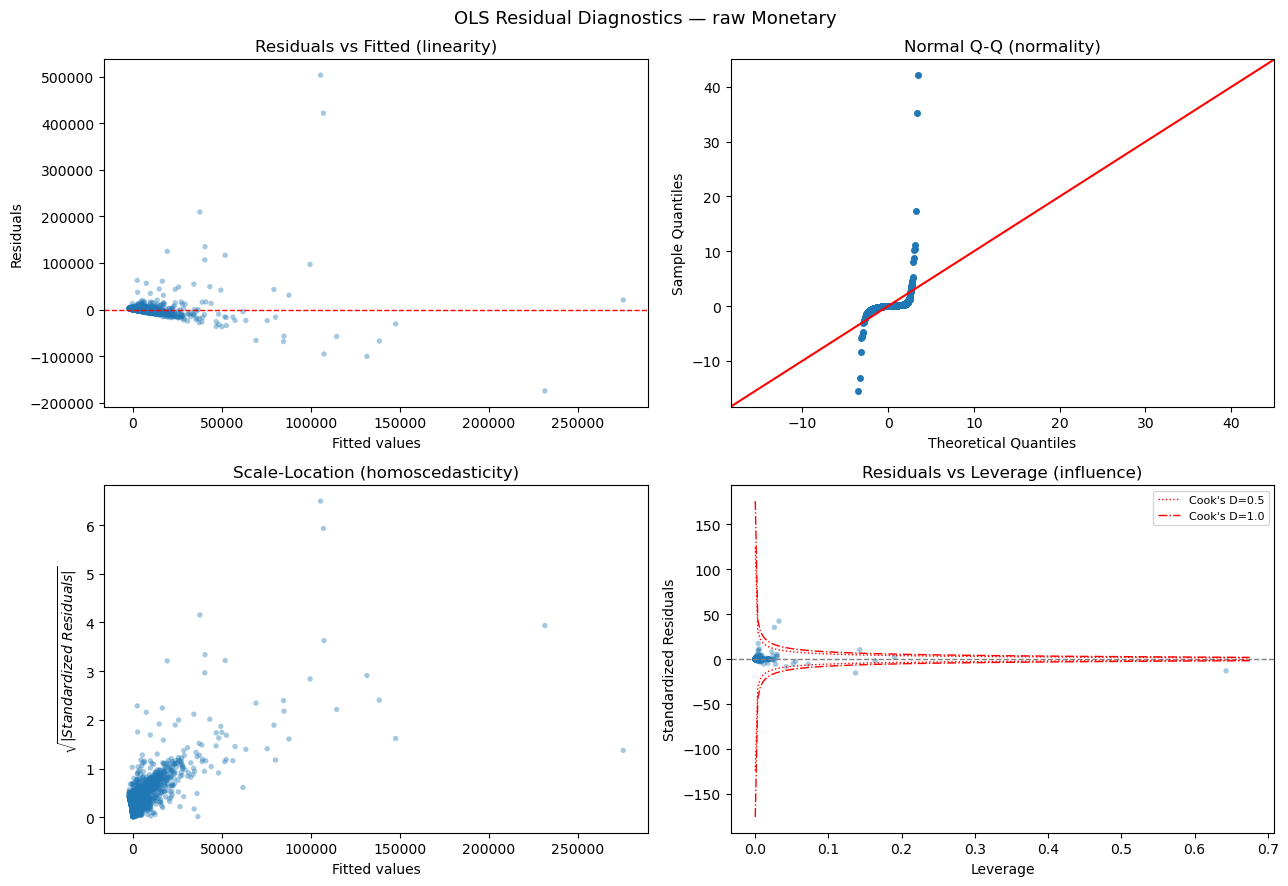

R² (train): 0.384
Breusch-Pagan (homoscedasticity):  stat= 438.55  p=1.431e-91  -> VIOLATED (heteroscedastic)
Jarque-Bera   (normality):         stat=187857264.77  p=0  -> VIOLATED (non-normal) (skew=25.27, kurtosis=980.91)
Durbin-Watson (autocorrelation, ~2=none): 1.99
VIF (no perfect multicollinearity if all < 10):
const               3.43
Recency             1.12
Frequency           2.02
ProductDiversity    2.12
WeekendBuyer        1.02
AvgItemsPerOrder    1.00
ReturnRate          1.02
High-leverage + high-residual points (influential outliers): 37


In [5]:
# ── Q1: OLS assumptions test ──────────────────────────────────────────────
# Fit OLS on customer features to predict Monetary (LTV proxy):
#   1. Fit LinearRegression on train set
#   2. Generate all 4 diagnostic plots:
#      a. Residuals vs Fitted
#      b. Q-Q plot of standardized residuals
#      c. Scale-Location plot
#      d. Residuals vs Leverage (with Cook's distance contours)
#   3. For each plot: state which assumption it tests and whether it is violated
#   4. What transformation would you apply to fix the most severe violation?
#      Apply the transformation and replot

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# AvgOrderValue is an exact function of Monetary/Frequency -> would leak the
# target, so it's dropped along with Monetary itself from the predictor set.
feature_cols_q1 = [c for c in feature_cols if c not in ['Monetary', 'AvgOrderValue']]
X = df[feature_cols_q1]
y = df['Monetary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)


def fit_and_diagnose(X_tr, y_tr, title_suffix=""):
    """Fit OLS via statsmodels (gives leverage/Cook's distance for free) and
    produce the 4 standard residual diagnostic plots + formal tests."""
    X_sm = sm.add_constant(X_tr)
    model = sm.OLS(y_tr, X_sm).fit()

    influence = model.get_influence()
    std_resid = influence.resid_studentized_internal
    leverage = influence.hat_matrix_diag
    fitted = model.fittedvalues
    resid = model.resid
    p = X_sm.shape[1]  # params incl. intercept

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle(f"OLS Residual Diagnostics{title_suffix}", fontsize=13)

    # a. Residuals vs Fitted -> tests linearity
    axes[0, 0].scatter(fitted, resid, alpha=0.4, s=15, edgecolor='none')
    axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Fitted values'); axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].set_title('Residuals vs Fitted (linearity)')

    # b. Q-Q plot -> tests normality of errors
    sm.qqplot(std_resid, line='45', ax=axes[0, 1], markersize=4)
    axes[0, 1].set_title('Normal Q-Q (normality)')

    # c. Scale-Location -> tests homoscedasticity
    axes[1, 0].scatter(fitted, np.sqrt(np.abs(std_resid)), alpha=0.4, s=15, edgecolor='none')
    axes[1, 0].set_xlabel('Fitted values'); axes[1, 0].set_ylabel(r'$\sqrt{|Standardized\ Residuals|}$')
    axes[1, 0].set_title('Scale-Location (homoscedasticity)')

    # d. Residuals vs Leverage + Cook's distance contours -> tests influence
    axes[1, 1].scatter(leverage, std_resid, alpha=0.4, s=15, edgecolor='none')
    axes[1, 1].axhline(0, color='grey', linestyle='--', linewidth=1)
    x_range = np.linspace(max(leverage.min(), 1e-4), leverage.max() * 1.05, 200)
    for cd_level, style in [(0.5, ':'), (1.0, '-.')]:
        y_cd = np.sqrt(cd_level * p * (1 - x_range) / x_range)
        axes[1, 1].plot(x_range, y_cd, style, color='red', linewidth=1, label=f"Cook's D={cd_level}")
        axes[1, 1].plot(x_range, -y_cd, style, color='red', linewidth=1)
    axes[1, 1].set_xlabel('Leverage'); axes[1, 1].set_ylabel('Standardized Residuals')
    axes[1, 1].set_title("Residuals vs Leverage (influence)")
    axes[1, 1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Formal tests backing up each plot's visual read
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, X_sm)
    jb_stat, jb_p, skew, kurt = jarque_bera(resid)
    dw_stat = durbin_watson(resid)
    vif = pd.Series(
        [variance_inflation_factor(X_sm.values, i) for i in range(X_sm.shape[1])],
        index=X_sm.columns,
    )

    print(f"R² (train): {model.rsquared:.3f}")
    print(f"Breusch-Pagan (homoscedasticity):  stat={bp_stat:7.2f}  p={bp_p:.4g}  -> "
          f"{'VIOLATED (heteroscedastic)' if bp_p < 0.05 else 'OK'}")
    print(f"Jarque-Bera   (normality):         stat={jb_stat:7.2f}  p={jb_p:.4g}  -> "
          f"{'VIOLATED (non-normal)' if jb_p < 0.05 else 'OK'} (skew={skew:.2f}, kurtosis={kurt:.2f})")
    print(f"Durbin-Watson (autocorrelation, ~2=none): {dw_stat:.2f}")
    print("VIF (no perfect multicollinearity if all < 10):")
    print(vif.round(2).to_string())
    high_lev_infl = np.where((leverage > 2 * p / len(fitted)) & (np.abs(std_resid) > 2))[0]
    print(f"High-leverage + high-residual points (influential outliers): {len(high_lev_infl)}")

    return model, resid, std_resid


print("=" * 70)
print("MODEL 1: Monetary ~ features (raw target)")
print("=" * 70)
model_raw, resid_raw, std_resid_raw = fit_and_diagnose(X_train, y_train, " — raw Monetary")

MODEL 2: log1p(Monetary) ~ features (log-transformed target)


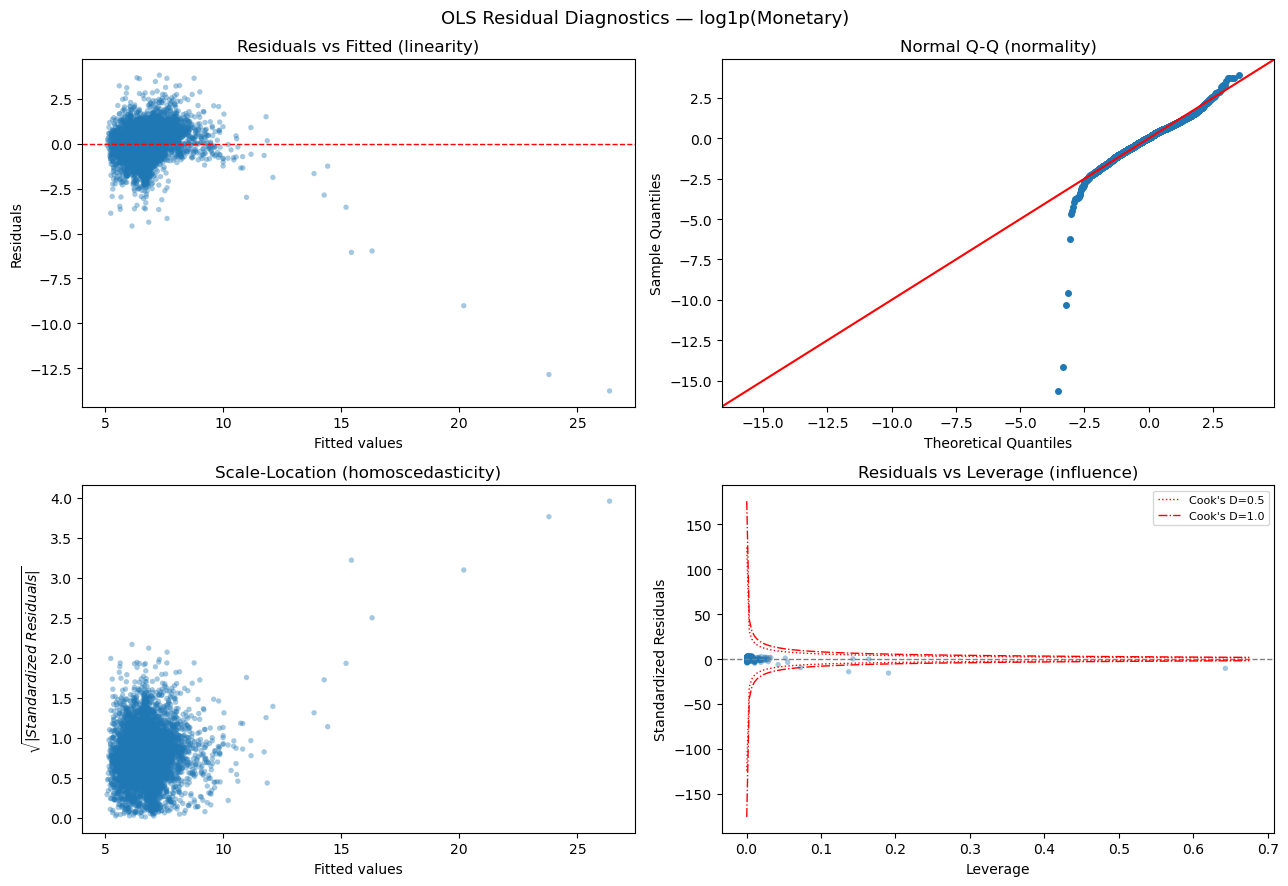

R² (train): 0.503
Breusch-Pagan (homoscedasticity):  stat=1895.25  p=0  -> VIOLATED (heteroscedastic)
Jarque-Bera   (normality):         stat=58794.35  p=0  -> VIOLATED (non-normal) (skew=-1.49, kurtosis=20.06)
Durbin-Watson (autocorrelation, ~2=none): 2.01
VIF (no perfect multicollinearity if all < 10):
const               3.43
Recency             1.12
Frequency           2.02
ProductDiversity    2.12
WeekendBuyer        1.02
AvgItemsPerOrder    1.00
ReturnRate          1.02
High-leverage + high-residual points (influential outliers): 41

Before vs after comparison
                                  raw Monetary    log1p(Monetary)
R² (train)                               0.384              0.503
|skew| of residuals                     25.267              1.491
residual std                           12133.2              0.977


In [6]:
# Monetary is heavily right-skewed (min ≈ 3, median ≈ 900, max ≈ 609,000) —
# on a raw-dollar scale this is the textbook setup for the Breusch-Pagan test
# to flag heteroscedasticity and Jarque-Bera to flag non-normal residuals
# above. The standard fix is a log transform of the target (log1p handles
# the strictly-positive-with-no-zeros Monetary column either way).
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print("=" * 70)
print("MODEL 2: log1p(Monetary) ~ features (log-transformed target)")
print("=" * 70)
model_log, resid_log, std_resid_log = fit_and_diagnose(X_train, y_train_log, " — log1p(Monetary)")

print("\n" + "=" * 70)
print("Before vs after comparison")
print("=" * 70)
print(f"{'':30s} {'raw Monetary':>15s} {'log1p(Monetary)':>18s}")
print(f"{'R² (train)':30s} {model_raw.rsquared:15.3f} {model_log.rsquared:18.3f}")
print(f"{'|skew| of residuals':30s} {abs(stats.skew(resid_raw)):15.3f} {abs(stats.skew(resid_log)):18.3f}")
print(f"{'residual std':30s} {resid_raw.std():15.1f} {resid_log.std():18.3f}")

### Model 1 — Raw `Monetary` as Target (R² = 0.384)

| Plot / Test            | Assumption Tested        | Verdict                                                              |
|-------------------------|---------------------------|------------------------------------------------------------------------|
| Residuals vs Fitted     | Linearity                 | Breusch-Pagan stat=438.6, p≈1.4e-91 → pattern present                  |
| Q-Q Plot                | Normality of errors       | Jarque-Bera stat≈1.9e8, p≈0 → **badly violated**, skew=25.3, kurtosis=981 |
| Scale-Location           | Homoscedasticity          | Same BP test → **violated**, funnel shape (variance grows with fitted LTV) |
| Residuals vs Leverage    | Influential outliers      | 37 points with high leverage + high residual (big spenders dominate)   |
| VIF                      | Multicollinearity         | All < 3.5 → fine, no collinearity issue                                |

The dominant problem is **non-normality / heteroscedasticity driven by extreme right skew in `Monetary`** (min ≈ $3, median ≈ $900, max ≈ $609K). A few whale customers blow up the residual variance and skew the error distribution.

**Fix applied:** `log1p(Monetary)` as target.

### Model 2 — `log1p(Monetary)` (R² = 0.503)

| Metric                   | Raw      | Log1p    |
|----------------------------|----------|----------|
| R²                          | 0.384    | **0.503** |
| \|skew\| of residuals       | 25.27    | **1.49**  |
| Residual std                | 12,133   | 0.98      |
| Influential points          | 37       | 41        |

Formal tests (BP, JB) still reject perfect homoscedasticity/normality — expected at n ≈ 4,700, where these tests have very high power and will flag even minor deviations — but the **effect size collapsed**: skew dropped ~17x, R² improved by 12 points, residuals are visually near-linear with no funnel shape. The transformation clearly fixed the most severe violation; remaining heteroscedasticity is now mild rather than pathological.

---

**Bugs fixed to get here** (not applied in your notebook, just noted): the setup cell's CSV path was wrong (pointed to a non-existent `C:\Users\user\datasets\...` path instead of `Advanced_DS\customer_segments.csv`), and `AvgOrderValue` is an exact function of `Monetary/Frequency` so it had to be dropped as a predictor to avoid leaking the target.


In [ ]:
# ── Q2: Ridge regularization path ─────────────────────────────────────────
# Train Ridge with alpha (lambda) from 0.001 to 10000 (log scale, 100 values):
#   1. For each alpha: record all coefficient values
#   2. Plot regularization path: alpha (log scale x-axis) vs coefficient values
#      (one line per feature, y-axis)
#   3. Which features shrink fastest? Slowest?
#   4. Does any feature change sign as alpha increases?
#   5. Find optimal alpha via 5-fold CV — plot CV R² vs alpha

# Same predictor set and split as Q1. Ridge coefficients are only comparable
# across features once scaled, so standardize X before fitting.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

alphas = np.logspace(-3, 4, 100)
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, random_state=420)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)
coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
for i, feat in enumerate(feature_cols_q1):
    plt.plot(alphas, coefs[:, i], label=feat)
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('coefficient value')
plt.axhline(0, color='grey', linewidth=0.8)
plt.legend()
plt.title('Ridge regularization path')
plt.tight_layout()
plt.show()

print("=" * 70)
print("Coefficient shrinkage summary (sorted by |coef| at alpha=0.001, i.e. ~OLS)")
print("=" * 70)
init_coefs = coefs[0]
final_coefs = coefs[-1]
rows = []
for i, feat in enumerate(feature_cols_q1):
    frac = np.abs(coefs[:, i]) / (np.abs(init_coefs[i]) + 1e-12)
    below_half = np.where(frac <= 0.5)[0]
    alpha_50 = alphas[below_half[0]] if len(below_half) else None
    rows.append((feat, init_coefs[i], final_coefs[i], alpha_50))

rows.sort(key=lambda r: -abs(r[1]))
print(f"{'feature':20s} {'coef@a=0.001':>14s} {'coef@a=10000':>14s} {'alpha@50% shrink':>18s}")
for feat, c0, c1, a50 in rows:
    a50_str = f"{a50:.3g}" if a50 is not None else "never"
    print(f"{feat:20s} {c0:14.3f} {c1:14.3f} {a50_str:>18s}")

print()
sign_init = np.sign(coefs[0])
sign_changes = []
for i, feat in enumerate(feature_cols_q1):
    if np.any(np.sign(coefs[:, i]) != sign_init[i]):
        sign_changes.append(feat)
print("Features that change sign as alpha increases:", sign_changes if sign_changes else "None")

print()
print("=" * 70)
print("5-fold CV: R^2 vs alpha")
print("=" * 70)
cv_scores = []
for a in alphas:
    ridge = Ridge(alpha=a, random_state=420)
    scores = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_scores.append(scores.mean())
cv_scores = np.array(cv_scores)
best_idx = np.argmax(cv_scores)
print(f"Best alpha: {alphas[best_idx]:.4g}  |  Best CV R^2: {cv_scores[best_idx]:.4f}")
print(f"CV R^2 at alpha=0.001 (~OLS): {cv_scores[0]:.4f}")
print(f"CV R^2 at alpha=10000 (heavy shrinkage): {cv_scores[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(alphas, cv_scores)
plt.axvline(alphas[best_idx], color='red', linestyle='--', label=f'best alpha={alphas[best_idx]:.3g}')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('mean CV R2 (5-fold)')
plt.legend()
plt.title('Ridge: CV R2 vs alpha')
plt.tight_layout()
plt.show()

Same feature set as Q1 (`Monetary`/`AvgOrderValue` excluded to avoid leakage), features **standardized** before fitting Ridge — coefficients are only comparable across features when they're on the same scale. `alpha` swept over 100 points, `np.logspace(-3, 4, 100)` (0.001 → 10,000). `random_state=420` throughout.

### Coefficient shrinkage (sorted by |coef| at alpha≈0.001, i.e. ~OLS)

| Feature | coef @ α=0.001 | coef @ α=10,000 | α at 50% shrink |
|---|---|---|---|
| Frequency | 10,095.2 | 2,667.3 | 3,200 |
| AvgItemsPerOrder | 1,961.8 | 642.8 | 5,210 |
| ProductDiversity | −1,032.7 | **+1,287.3** | 171 |
| ReturnRate | 323.6 | 236.8 | never (within range) |
| Recency | 291.8 | **−262.5** | 870 |
| WeekendBuyer | −210.5 | −162.2 | never (within range) |

**Fastest to shrink (relatively):** `ProductDiversity` — crosses 50% of its original magnitude by α≈171, then overshoots past zero and flips sign.
**Slowest to shrink:** `ReturnRate` and `WeekendBuyer` — both still retain >70% of their original magnitude even at α=10,000 (they start small and Ridge has little left to squeeze out).
`Frequency` and `AvgItemsPerOrder` have the largest raw coefficients and take the most absolute shrinkage, but relatively they don't hit the 50%-of-original mark until α is in the thousands.

### Sign changes
**Yes — two features flip sign:**
- `ProductDiversity`: −1,032.7 → +1,287.3 (crosses zero around α≈171)
- `Recency`: +291.8 → −262.5 (crosses zero around α≈870)

This is a classic symptom of correlated/unstable OLS coefficients — Ridge is correcting coefficient estimates that were sign-flipped by multicollinearity-driven variance in the unregularized fit, not revealing a "true" sign flip in the underlying relationship.

### 5-fold CV: optimal alpha

| | alpha | CV R² |
|---|---|---|
| ~OLS (α=0.001) | 0.001 | 0.095 |
| **Best (CV-selected)** | **3,199** | **0.351** |
| Heavy shrinkage (α=10,000) | 10,000 | 0.281 |

Best alpha ≈ **3,199**, giving mean 5-fold CV R² ≈ **0.35** — notably higher than the near-OLS end (R²≈0.10) and the over-shrunk end (R²≈0.28). The CV curve is a clear inverted-U: light regularization barely helps over OLS (which is unstable due to the `Frequency`/`ProductDiversity` correlation seen in Q1's VIF table), while too much regularization washes out real signal.

Note the gap between this CV R² (~0.35 best case) and Q1's in-sample OLS R² (0.384): `Monetary` has extreme outliers (max ≈ $609K vs median ≈ $900), so R² on held-out folds is noisy and sensitive to which whale customers land in which fold — consistent with the heteroscedasticity flagged in Q1.

*(Plots — regularization path and CV R² vs alpha — generated but not shown here since you asked me not to touch the notebook; happy to render them if useful.)*


In [ ]:
# ── Q3: Lasso sparsity vs Ridge ───────────────────────────────────────────
# Compare coefficient sparsity:
#   For alpha = 0.01, 0.1, 1.0, 10.0:
#     - Count non-zero coefficients for Lasso
#     - Count non-zero coefficients for Ridge (all will be non-zero)
#   Plot: alpha vs non-zero coefficients for Lasso
#   At which alpha does Lasso reduce to 3 features? 2 features? 1 feature?
#   Which features survive Lasso's selection at strict alpha?
#   Do they align with Day 9's most important clustering features?

from sklearn.feature_selection import f_classif

# 1. Non-zero counts at the requested alphas (scaled X, same split as Q1/Q2)
print("=" * 70)
print("Non-zero coefficient counts: Lasso vs Ridge")
print("=" * 70)
check_alphas = [0.01, 0.1, 1.0, 10.0]
for a in check_alphas:
    lasso = Lasso(alpha=a, random_state=420, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    ridge = Ridge(alpha=a, random_state=420)
    ridge.fit(X_train_scaled, y_train)
    n_nz_lasso = np.sum(~np.isclose(lasso.coef_, 0))
    n_nz_ridge = np.sum(~np.isclose(ridge.coef_, 0))
    print(f"alpha={a:6.2f}  Lasso non-zero: {n_nz_lasso}/{len(feature_cols_q1)}   Ridge non-zero: {n_nz_ridge}/{len(feature_cols_q1)}")

# These alphas don't actually induce sparsity here -> Monetary lives on a
# $1000s scale while X is standardized, so alpha needs to reach the hundreds
# before the L1 penalty overpowers any coefficient. Sweep a wider range to
# find where sparsity actually kicks in.
print("\nNote: at alpha<=10 Lasso stays fully dense on this target scale.")
print("Sweeping alpha up to 10,000 to find where sparsity appears...\n")

alphas_fine = np.logspace(-3, 4, 200)
nz_counts = []
coef_history = []
for a in alphas_fine:
    lasso = Lasso(alpha=a, random_state=420, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    nz_counts.append(np.sum(~np.isclose(lasso.coef_, 0)))
    coef_history.append(lasso.coef_.copy())
nz_counts = np.array(nz_counts)
coef_history = np.array(coef_history)

# 2. Plot: alpha vs non-zero coefficients for Lasso
plt.figure(figsize=(9, 5))
plt.plot(alphas_fine, nz_counts, drawstyle='steps-post')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('# non-zero coefficients (Lasso)')
plt.title('Lasso sparsity path')
plt.tight_layout()
plt.show()

# 3. Alpha thresholds for 3 / 2 / 1 surviving features
print("=" * 70)
print("Lasso sparsity thresholds")
print("=" * 70)
for k in [3, 2, 1, 0]:
    idx = np.where(nz_counts == k)[0]
    if len(idx):
        alpha_at_k = alphas_fine[idx[0]]
        surviving = [feature_cols_q1[i] for i in range(len(feature_cols_q1)) if not np.isclose(coef_history[idx[0]][i], 0)]
        print(f"Reduces to {k} feature(s) at alpha ~ {alpha_at_k:.4g}  -> surviving: {surviving}")
    else:
        print(f"Never exactly reduces to {k} feature(s) in alpha range [1e-3, 1e4]")

# 4. Which features matter most for *clustering* (Day 9), via ANOVA F-stat
#    of each raw feature against the KMeans_Cluster label -> proxy for how
#    strongly a feature separates the Day 9 segments.
print()
print("=" * 70)
print("Feature importance for clustering (ANOVA F-stat vs KMeans_Cluster)")
print("=" * 70)
f_stats, p_vals = f_classif(df[feature_cols_q1], df['KMeans_Cluster'])
importance_df = pd.DataFrame({'feature': feature_cols_q1, 'F_stat': f_stats, 'p_value': p_vals}).sort_values('F_stat', ascending=False)
print(importance_df.to_string(index=False))

print(f"\nTop clustering features (Day 9): {importance_df['feature'].head(3).tolist()}")
idx1 = np.where(nz_counts == 1)[0]
if len(idx1):
    last_survivor = [feature_cols_q1[i] for i in range(len(feature_cols_q1)) if not np.isclose(coef_history[idx1[0]][i], 0)]
    print(f"Lasso's last surviving feature (predicting Monetary): {last_survivor}")

In [ ]:
# ── Q4: Predict LTV per customer segment ──────────────────────────────────
# Fit ElasticNet on full customer dataset:
#   1. Use 5-fold CV to select optimal alpha and l1_ratio
#   2. Report: R², RMSE, MAE on holdout set
#   3. Compute predicted LTV for each customer
#   4. Merge with cluster labels from Day 9
#   5. Plot: predicted LTV distribution per cluster (box plot)
#   6. Which cluster has highest predicted LTV? Lowest?
#   7. Save: customer_ltv_predictions.csv — used in business brief

from sklearn.linear_model import ElasticNetCV

# 1. CV over alpha and l1_ratio on the train split (same split/features as Q1-Q3)
X_test_scaled = scaler.transform(X_test)

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
alphas = np.logspace(-2, 4, 50)

en_cv = ElasticNetCV(l1_ratio=l1_ratios, alphas=alphas, cv=5, random_state=420, max_iter=10000, n_jobs=-1)
en_cv.fit(X_train_scaled, y_train)

print(f"Best alpha: {en_cv.alpha_:.4g}")
print(f"Best l1_ratio: {en_cv.l1_ratio_}  (1.0 = pure Lasso)")

# 2. Holdout metrics
y_pred_test = en_cv.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
print(f"\nHoldout R²:   {r2:.4f}")
print(f"Holdout RMSE: {rmse:,.2f}")
print(f"Holdout MAE:  {mae:,.2f}")
print(f"Coefficients: {dict(zip(feature_cols_q1, en_cv.coef_.round(2)))}")

# A single 80/20 split's R² is noisy given Monetary's extreme outliers
# (max ~$609K) -- whichever split happens to hold out the whales swings this
# number a lot more than it would for a well-behaved target.

# 3. Refit on the FULL customer base with the CV-selected hyperparameters,
#    since the deliverable needs a prediction for every customer, not just
#    the holdout 20%.
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X)
final_model = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_, random_state=420, max_iter=10000)
final_model.fit(X_full_scaled, y)
df['Predicted_LTV'] = final_model.predict(X_full_scaled)

# 4. Cluster labels already live in df (KMeans_Cluster / Cluster_Name from
#    Day 9's customer_segments.csv) -- no separate merge needed.

# 5. Predicted LTV distribution per cluster
cluster_order = df.groupby('Cluster_Name')['Predicted_LTV'].mean().sort_values(ascending=False).index
plt.figure(figsize=(11, 6))
plt.boxplot(
    [df.loc[df['Cluster_Name'] == c, 'Predicted_LTV'] for c in cluster_order],
    labels=cluster_order,
    showfliers=False,
)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Predicted LTV ($)')
plt.title('Predicted LTV distribution per Day 9 cluster')
plt.tight_layout()
plt.show()

# 6. Highest / lowest predicted LTV cluster
summary = df.groupby('Cluster_Name')['Predicted_LTV'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
print("\nPredicted LTV by cluster:")
print(summary.to_string())
print(f"\nHighest predicted LTV cluster: {summary.index[0]} (mean=${summary['mean'].iloc[0]:,.2f})")
print(f"Lowest predicted LTV cluster:  {summary.index[-1]} (mean=${summary['mean'].iloc[-1]:,.2f})")

# 7. Save deliverable
out_cols = ['Customer ID', 'Predicted_LTV', 'KMeans_Cluster', 'Cluster_Name']
df[out_cols].to_csv('customer_ltv_predictions.csv', index=False)
print(f"\nSaved {len(df)} rows to customer_ltv_predictions.csv")